# Comparação de Modelos de Risco de Crédito: Regressão Logística vs Random Forest

Este notebook realiza a comparação entre dois modelos de aprendizado de máquina aplicados a dados de empréstimos (Lending Club), incluindo métricas avançadas como AUC-ROC, KS e Brier Score.

**Objetivo:** Classificar se um empréstimo será pago (0) ou resultará em inadimplência (1).

## 1. Importação de Bibliotecas

In [11]:
import pandas as pd
import numpy as np
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# Configuração de display do Pandas
pd.set_option('display.max_columns', None)





## 2. Carregamento dos Dados

In [12]:
print("--- 1. Carregando Dados ---")
try:
    # Tenta baixar/acessar dataset do Kaggle (faz download automático e cache)
    handle = "adarshsng/lending-club-loan-data-csv"
    dataset_dir = Path(kagglehub.dataset_download(handle))
    csv_files = list(dataset_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError("Nenhum CSV encontrado.")

    main_csv = max(csv_files, key=lambda p: p.stat().st_size)
    print(f"CSV selecionado: {main_csv}")

    # low_memory=False pois o dataset tem colunas mistas
    df = pd.read_csv(main_csv, low_memory=False)
    print(f"Dataset carregado. Dimensões: {df.shape}")
except Exception as e:
    print(f"Erro ao carregar do Kaggle: {e}")
    print("Verifique se o arquivo CSV está acessível.")










--- 1. Carregando Dados ---
CSV selecionado: C:\Users\thayn\.cache\kagglehub\datasets\adarshsng\lending-club-loan-data-csv\versions\1\loan.csv
Dataset carregado. Dimensões: (2260668, 145)


## 3. Seleção de Colunas

In [21]:
# Limpeza nomes colunas
def clean_colname(c):
    return str(c).replace("\u00a0", " ").replace("\ufeff", "").strip()

df.columns = [clean_colname(c) for c in df.columns]

# Lista de colunas relevantes para a análise preliminar (24 colunas)
selected_cols_20 = [
    "id", "loan_status", "loan_amnt", "term", "installment", 
    "purpose", "annual_inc", "verification_status", "dti", 
    "emp_length", "home_ownership", "fico_range_low", "delinq_2yrs", 
    "inq_last_6mths", "revol_util", "open_acc", "total_acc", "revol_bal", 
    "pub_rec_bankruptcies", "addr_state", "issue_d"
]

# Ajuste para fallback de colunas (caso nomes variem entre versões do dataset)
if "sub_grade" not in df.columns and "grade" in df.columns:
    selected_cols_20 = ["grade" if c == "sub_grade" else c for c in selected_cols_20]
if "fico_range_low" not in df.columns and "fico_range_high" in df.columns:
    selected_cols_20 = ["fico_range_high" if c == "fico_range_low" else c for c in selected_cols_20]

available_cols = [c for c in selected_cols_20 if c in df.columns]
df_20 = df[available_cols].copy()
print(f"Colunas selecionadas: {len(available_cols)}")
df_20.head()










Colunas selecionadas: 20


,id,loan_status,loan_amnt,term,installment,purpose,annual_inc,verification_status,dti,emp_length,home_ownership,delinq_2yrs,inq_last_6mths,revol_util,open_acc,total_acc,revol_bal,pub_rec_bankruptcies,addr_state,issue_d
0,NaN,Current,2500,36 months,84.92,debt_consolidation,55000.0,Not Verified,18.24,10+ years,RENT,0.0,1.0,10.3,9.0,34.0,4341,1.0,NY,Dec-2018
1,NaN,Current,30000,60 months,777.23,debt_consolidation,90000.0,Source Verified,26.52,10+ years,MORTGAGE,0.0,0.0,24.2,13.0,44.0,12315,1.0,LA,Dec-2018
2,NaN,Current,5000,36 months,180.69,debt_consolidation,59280.0,Source Verified,10.51,6 years,MORTGAGE,0.0,0.0,19.1,8.0,13.0,4599,0.0,MI,Dec-2018
3,NaN,Current,4000,36 months,146.51,debt_consolidation,92000.0,Source Verified,16.74,10+ years,MORTGAGE,0.0,0.0,78.1,10.0,13.0,5468,0.0,WA,Dec-2018
4,NaN,Current,30000,60 months,731.78,debt_consolidation,57250.0,Not Verified,26.35,10+ years,MORTGAGE,0.0,0.0,3.6,12.0,26.0,829,0.0,MD,Dec-2018


## 4. Pré-processamento

In [23]:
print("\n--- 3. Pré-processamento ---")

# 4.1 Tratamento do Target (loan_status)
target_map = {
    'Fully Paid': 0, 
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Charged Off': 1, 
    'Default': 1, 
    'Does not meet the credit policy. Status:Charged Off': 1
}

# Filtrar apenas as linhas com os status mapeados acima
df_clean = df_20[df_20['loan_status'].isin(target_map.keys())].copy()
df_clean['target'] = df_clean['loan_status'].map(target_map)

print(f"Linhas após filtro de status: {len(df_clean)}")
print("Distribuição do Target:")
print(df_clean['target'].value_counts(normalize=True))

# Garantir que issue_year seja criada antes do drop
if 'issue_d' in df_clean.columns:
    df_clean['issue_d_dt'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y', errors='coerce')
    df_clean['issue_year'] = df_clean['issue_d_dt'].dt.year
    print(f"Anos disponíveis: {sorted(df_clean['issue_year'].dropna().unique().astype(int))}")
else:
    print("ATENÇÃO: coluna issue_d não encontrada")

# 4.2 Limpeza Numérica e Conversões
# 'term' (ex: " 36 months" -> 36)
if 'term' in df_clean.columns:
    df_clean['term_months'] = df_clean['term'].astype(str).str.extract(r'(\d+)').astype(float)

# 'emp_length' (ex: "< 1 year" -> 0, "10+ years" -> 10)
def parse_emp_length(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if '<' in x: return 0
    if '+' in x: return 10
    # Extrai apenas os dígitos
    nums = ''.join(filter(str.isdigit, x))
    return float(nums) if nums else np.nan

if 'emp_length' in df_clean.columns:
    df_clean['emp_length_years'] = df_clean['emp_length'].apply(parse_emp_length)

# 4.3 Tratamento de Data (issue_d) para Split Temporal
# Manter issue_d temporariamente para o split
if 'issue_d' in df_clean.columns:
    df_clean['issue_d_dt'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
    df_clean['issue_year'] = df_clean['issue_d_dt'].dt.year

# Remover colunas originais bruto ou identificadores (MANTENDO issue_d_dt e issue_year por enquanto)
drop_cols = ['id', 'member_id', 'loan_status', 'term', 'emp_length', 'issue_d', 'url', 'desc']
df_model = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# 4.4 Imputação de Nulos
# Numéricas: preencher com 0 (simplificação)
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].fillna(0)

# Categóricas: preencher com 'Unknown'
cat_cols = df_model.select_dtypes(exclude=[np.number, 'datetime']).columns
# Remove colunas de data e target da lista de categóricas
exclude_cols = ['issue_d_dt', 'issue_year', 'target']
cat_cols = [c for c in cat_cols if c not in exclude_cols]

for c in cat_cols:
    df_model[c] = df_model[c].fillna("Unknown")

# 4.5 One-Hot Encoding (Variáveis Dummy)
df_final = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f"Shape final dataset pronto para modelagem: {df_final.shape}")
print(f"Anos disponíveis: {sorted(df_final['issue_year'].unique()) if 'issue_year' in df_final.columns else 'N/A'}")











--- 3. Pré-processamento ---
Linhas após filtro de status: 1306387
Distribuição do Target:
target
0    0.799105
1    0.200895
Name: proportion, dtype: float64
Anos disponíveis: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Shape final dataset pronto para modelagem: (1306387, 86)
Anos disponíveis: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


## 5. Modelagem (Treinamento)

In [24]:
print("\n--- 4. Divisão Treino/Teste (Out-of-Time) ---")

# Definição dos períodos
train_end_year = 2016
test_start_year = 2017

# Split Temporal
if 'issue_year' in df_final.columns:
    mask_train = df_final['issue_year'] <= train_end_year
    mask_test = df_final['issue_year'] >= test_start_year
    
    X_train = df_final[mask_train].drop(columns=['target', 'issue_d_dt', 'issue_year'])
    y_train = df_final.loc[mask_train, 'target']
    
    X_test = df_final[mask_test].drop(columns=['target', 'issue_d_dt', 'issue_year'])
    y_test = df_final.loc[mask_test, 'target']
    
    print(f"Treino (<= {train_end_year}): {X_train.shape[0]} amostras")
    print(f"Teste (>= {test_start_year}): {X_test.shape[0]} amostras")
else:
    print("ERRO: Coluna 'issue_year' não encontrada. Usando random split (fallback).")
    X = df_final.drop(columns=['target'])
    y = df_final['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalonamento (Essencial para Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Regressão Logística ---
print("Treinando Regressão Logística com Balanceamento...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# Previsões
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = lr.predict(X_test_scaled)

# --- Random Forest ---
print("Treinando Random Forest com Balanceamento...")
# Aumentei n_estimators para 100 e adicionei class_weight='balanced'
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

# Previsões
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print("Treinamento Concluído!")











--- 4. Divisão Treino/Teste (Out-of-Time) ---
Treino (<= 2016): 1100286 amostras
Teste (>= 2017): 206101 amostras
Treinando Regressão Logística com Balanceamento...
Treinando Random Forest com Balanceamento...
Treinamento Concluído!


## 6. Avaliação e Comparação (Incluindo KS e Brier Score)


=== Regressão Logística ===
              precision    recall  f1-score   support

           0       0.86      0.69      0.76    162761
           1       0.33      0.58      0.42     43340

    accuracy                           0.66    206101
   macro avg       0.60      0.63      0.59    206101
weighted avg       0.75      0.66      0.69    206101

AUC-ROC: 0.6911
Brier Score: 0.2213
KS Statistic: 0.2807

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.70      0.77    162761
           1       0.32      0.53      0.40     43340

    accuracy                           0.66    206101
   macro avg       0.58      0.62      0.58    206101
weighted avg       0.74      0.66      0.69    206101

AUC-ROC: 0.6735
Brier Score: 0.2234
KS Statistic: 0.2518


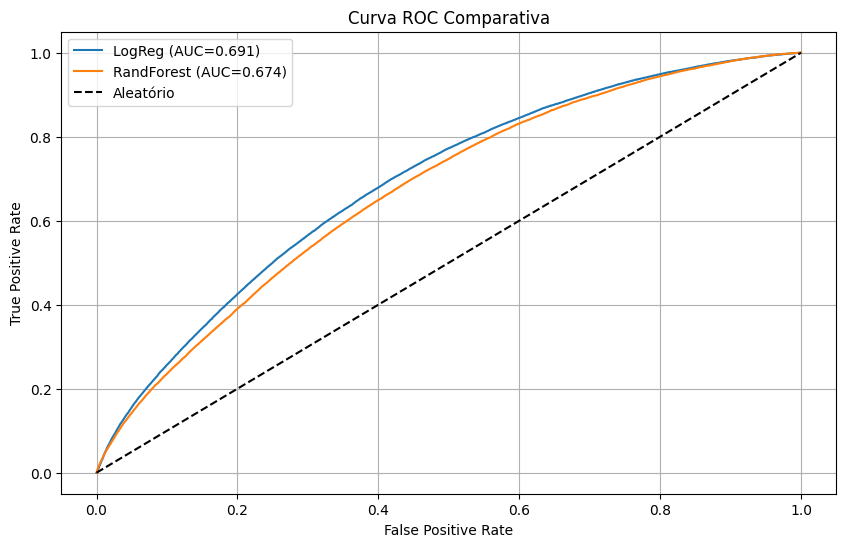

In [25]:
print("\n=== Regressão Logística ===")
print(classification_report(y_test, y_pred_lr))
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"AUC-ROC: {roc_auc_lr:.4f}")

# Brier Score
brier_lr = brier_score_loss(y_test, y_prob_lr)
print(f"Brier Score: {brier_lr:.4f}")

# KS (Kolmogorov-Smirnov)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
ks_lr = max(tpr_lr - fpr_lr)
print(f"KS Statistic: {ks_lr:.4f}")

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC-ROC: {roc_auc_rf:.4f}")

# Brier Score
brier_rf = brier_score_loss(y_test, y_prob_rf)
print(f"Brier Score: {brier_rf:.4f}")

# KS
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
ks_rf = max(tpr_rf - fpr_rf)
print(f"KS Statistic: {ks_rf:.4f}")

# Plot Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandForest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Comparativa')
plt.legend()
plt.grid(True)
plt.show()










In [29]:
# =========================================================
# Teste de DeLong — Comparação Estatística entre AUC-ROCs
# =========================================================
from scipy.stats import norm

def delong_test(y_true, y_score1, y_score2):
    """
    Teste de DeLong (1988) para comparação pareada de duas AUC-ROC.
    Retorna: AUC1, AUC2, z-statistic, p-valor (bicaudal),
             IC 95% para a diferença AUC1 - AUC2.
    Referência: DeLong et al. (1988) Biometrics 44(3):837-845.
    """
    y = np.asarray(y_true)
    s1 = np.asarray(y_score1)
    s2 = np.asarray(y_score2)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n1, n0 = len(pos_idx), len(neg_idx)

    def structural_components(scores):
        pos = scores[pos_idx]
        neg = scores[neg_idx]
        # V10: para cada positivo, fração de negativos com score menor
        V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        # V01: para cada negativo, fração de positivos com score maior
        V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        auc = np.mean(V10)
        return auc, V10, V01

    auc1, V10_1, V01_1 = structural_components(s1)
    auc2, V10_2, V01_2 = structural_components(s2)

    # Variâncias e covariância (estimador DeLong)
    var1  = np.var(V10_1, ddof=1) / n1 + np.var(V01_1, ddof=1) / n0
    var2  = np.var(V10_2, ddof=1) / n1 + np.var(V01_2, ddof=1) / n0
    cov12 = np.cov(V10_1, V10_2, ddof=1)[0,1] / n1 + \
            np.cov(V01_1, V01_2, ddof=1)[0,1] / n0

    diff    = auc1 - auc2
    se_diff = np.sqrt(var1 + var2 - 2 * cov12)
    z       = diff / se_diff
    p       = 2 * (1 - norm.cdf(abs(z)))

    # Intervalo de confiança 95% para a diferença
    ic_low  = diff - 1.96 * se_diff
    ic_high = diff + 1.96 * se_diff

    # IC 95% para cada AUC individualmente
    ic_auc1 = (auc1 - 1.96 * np.sqrt(var1), auc1 + 1.96 * np.sqrt(var1))
    ic_auc2 = (auc2 - 1.96 * np.sqrt(var2), auc2 + 1.96 * np.sqrt(var2))

    return {
        'AUC_LR'   : auc1,
        'AUC_RF'   : auc2,
        'IC95_LR'  : ic_auc1,
        'IC95_RF'  : ic_auc2,
        'diff'     : diff,
        'SE_diff'  : se_diff,
        'IC95_diff': (ic_low, ic_high),
        'z'        : z,
        'p_valor'  : p
    }


res = delong_test(y_test.values, y_prob_lr, y_prob_rf)

print('=== Teste de DeLong — Comparação AUC-ROC ===')
print(f"AUC Reg. Logística : {res['AUC_LR']:.4f}  "
      f"(IC 95%: {res['IC95_LR'][0]:.4f} – {res['IC95_LR'][1]:.4f})")
print(f"AUC Random Forest  : {res['AUC_RF']:.4f}  "
      f"(IC 95%: {res['IC95_RF'][0]:.4f} – {res['IC95_RF'][1]:.4f})")
print(f"Diferença (LR–RF)  : {res['diff']:.4f}  "
      f"(IC 95%: {res['IC95_diff'][0]:.4f} – {res['IC95_diff'][1]:.4f})")
print(f"Z (DeLong)         : {res['z']:.4f}")
print(f"p-valor (bicaudal) : {res['p_valor']:.4f}")
print()
if res['p_valor'] < 0.05:
    print('→ Diferença estatisticamente SIGNIFICATIVA (p < 0.05)')
    print('  A Regressão Logística apresenta AUC-ROC superior ao Random Forest.')
else:
    print('→ Diferença NÃO estatisticamente significativa (p >= 0.05)')
    print('  Os modelos apresentam desempenho equivalente em discriminação (AUC).')

=== Teste de DeLong — Comparação AUC-ROC ===
AUC Reg. Logística : 0.6911  (IC 95%: 0.6884 – 0.6938)
AUC Random Forest  : 0.6735  (IC 95%: 0.6708 – 0.6763)
Diferença (LR–RF)  : 0.0176  (IC 95%: 0.0159 – 0.0192)
Z (DeLong)         : 20.6803
p-valor (bicaudal) : 0.0000

→ Diferença estatisticamente SIGNIFICATIVA (p < 0.05)
  A Regressão Logística apresenta AUC-ROC superior ao Random Forest.


## 7. Visualização de Importância

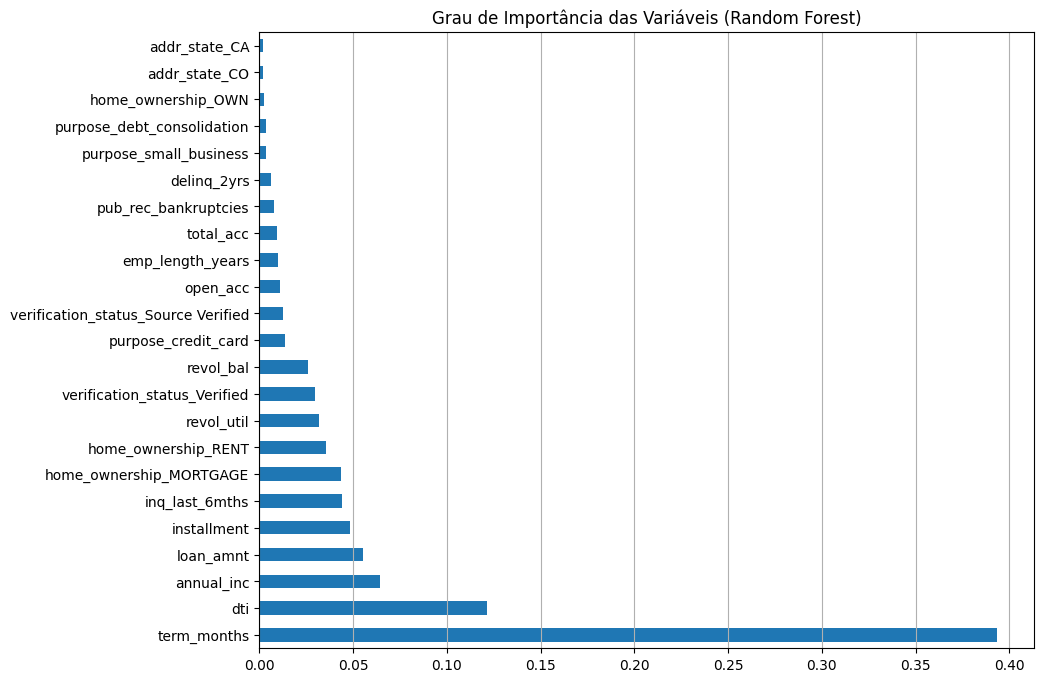

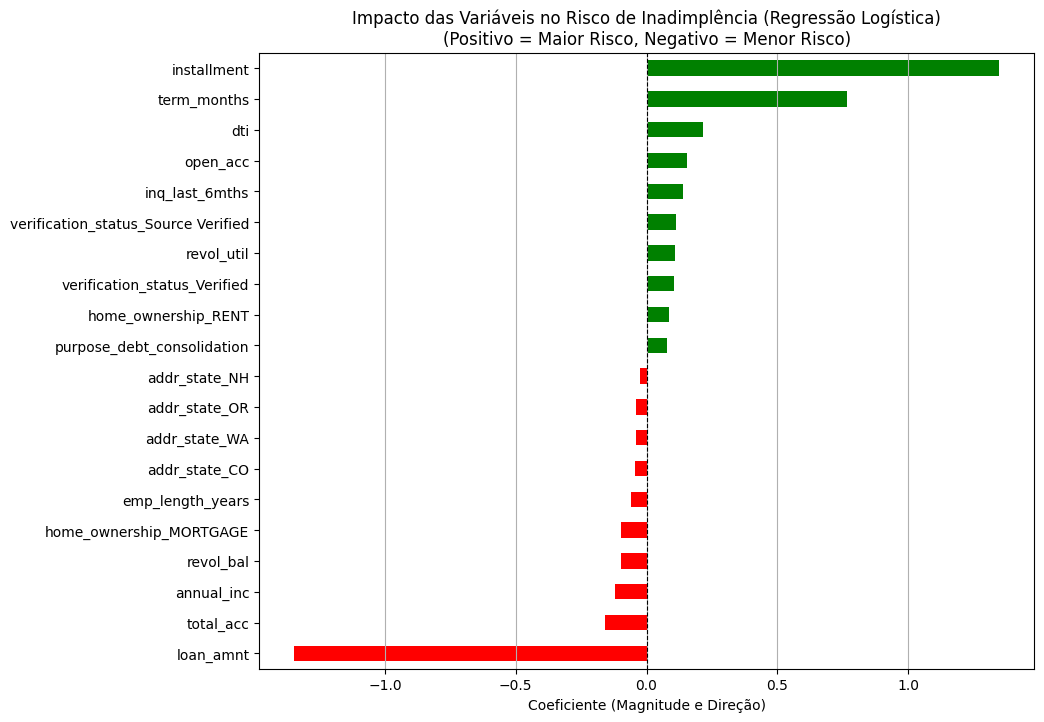

In [26]:
# Visualizar Feature Importance do Random Forest
if hasattr(rf, 'feature_importances_'):
    feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    plt.figure(figsize=(10, 8))
    feat_importances.nlargest(23).plot(kind='barh')
    plt.title('Grau de Importância das Variáveis (Random Forest)')
    plt.grid(True, axis='x')
    plt.show()

# Visualizar Coeficientes da Regressão Logística
if hasattr(lr, 'coef_'):
    # Extrair coeficientes e nomes das features
    coefs = pd.Series(lr.coef_[0], index=X_train.columns)
    
    # Selecionar os 10 maiores (positivos) e 10 menores (negativos)
    top_positive = coefs.nlargest(10)
    top_negative = coefs.nsmallest(10)
    top_coefs = pd.concat([top_positive, top_negative]).sort_values()

    plt.figure(figsize=(10, 8))
    colors = ['red' if x < 0 else 'green' for x in top_coefs]
    top_coefs.plot(kind='barh', color=colors)
    plt.title('Impacto das Variáveis no Risco de Inadimplência (Regressão Logística)\n(Positivo = Maior Risco, Negativo = Menor Risco)')
    plt.xlabel('Coeficiente (Magnitude e Direção)')
    plt.grid(True, axis='x')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.show()





## 8. PSI, Drift e Estabilidade Temporal

PSI - Regressão Logística : 0.0049
PSI - Random Forest       : 0.0063

Interpretação PSI LR : Estável (sem necessidade de revisão)
Interpretação PSI RF : Estável (sem necessidade de revisão)


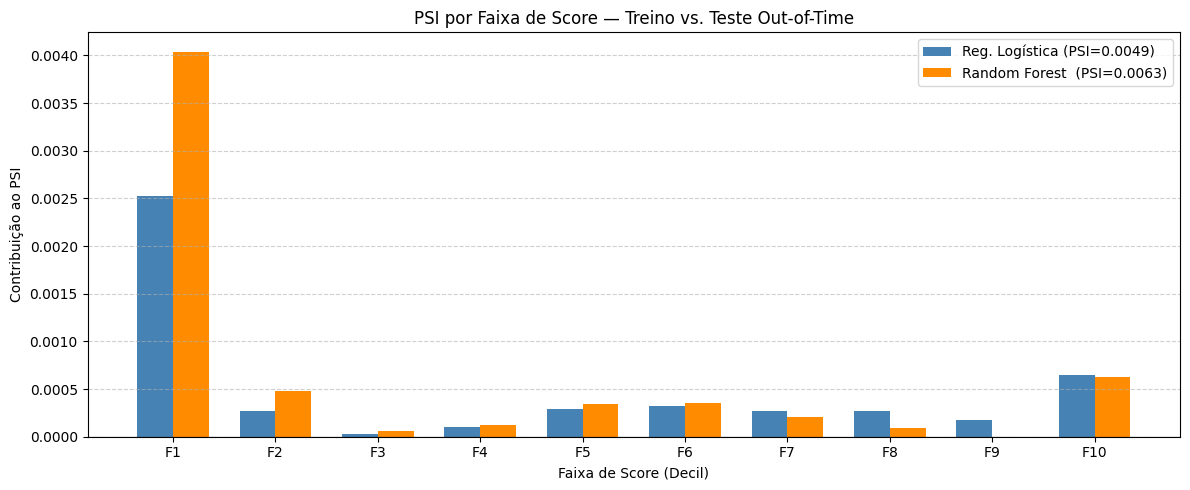

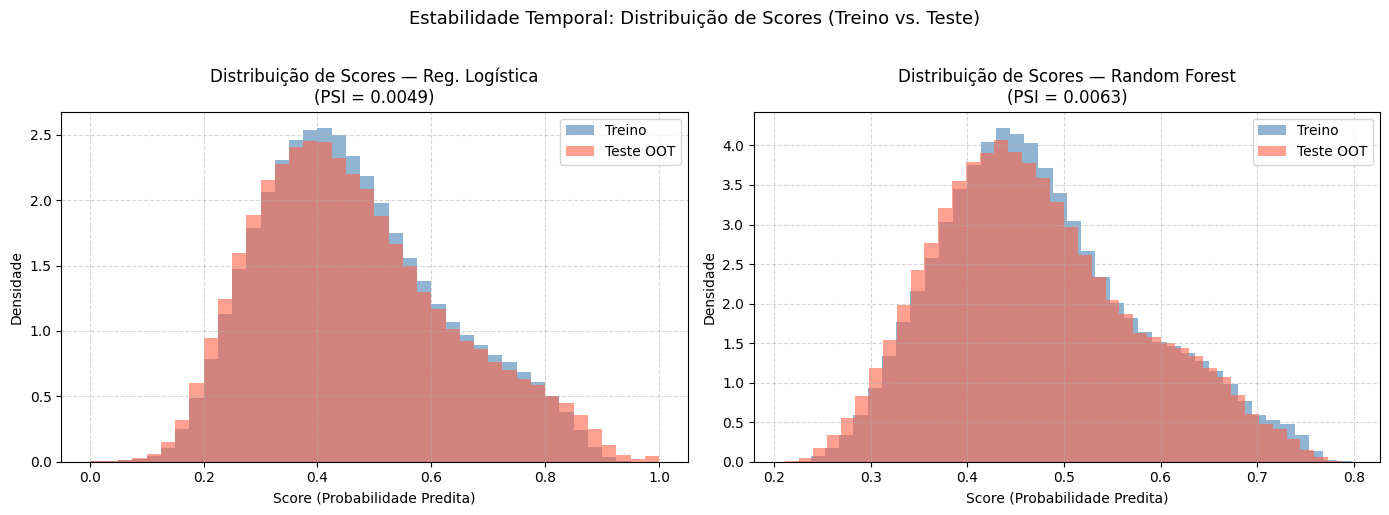

In [27]:
def calcular_psi(scores_treino, scores_teste, n_bins=10):
    """
    Calcula o Population Stability Index (PSI).
    Regras de interpretação:
      PSI < 0.10  -> estável (sem necessidade de revisão)
      0.10 <= PSI < 0.25 -> alerta (monitorar)
      PSI >= 0.25 -> instável (modelo necessita revisão)
    """
    # Define faixas com base nos quantis da distribuição de treino
    bins = np.percentile(scores_treino, np.linspace(0, 100, n_bins + 1))
    bins[0] = -np.inf
    bins[-1] = np.inf

    # Frequências relativas por faixa
    dist_treino, _ = np.histogram(scores_treino, bins=bins)
    dist_teste, _  = np.histogram(scores_teste,  bins=bins)

    dist_treino = dist_treino / len(scores_treino)
    dist_teste  = dist_teste  / len(scores_teste)

    # Evita divisão por zero substituindo zeros por valor muito pequeno
    dist_treino = np.where(dist_treino == 0, 1e-6, dist_treino)
    dist_teste  = np.where(dist_teste  == 0, 1e-6, dist_teste)

    # Fórmula PSI
    psi_por_faixa = (dist_teste - dist_treino) * np.log(dist_teste / dist_treino)
    psi_total     = np.sum(psi_por_faixa)

    return psi_total, psi_por_faixa, bins


# ---------------------------------------------------------
# Scores de treino: probabilidades na base de treino
# ---------------------------------------------------------
y_prob_lr_treino = lr.predict_proba(X_train_scaled)[:, 1]
y_prob_rf_treino = rf.predict_proba(X_train)[:, 1]

# ---------------------------------------------------------
# Calcular PSI para cada modelo
# ---------------------------------------------------------
psi_lr, psi_lr_faixas, bins_lr = calcular_psi(y_prob_lr_treino, y_prob_lr)
psi_rf, psi_rf_faixas, bins_rf = calcular_psi(y_prob_rf_treino, y_prob_rf)

print(f'PSI - Regressão Logística : {psi_lr:.4f}')
print(f'PSI - Random Forest       : {psi_rf:.4f}')
print()

def interpretar_psi(psi):
    if psi < 0.10:
        return 'Estável (sem necessidade de revisão)'
    elif psi < 0.25:
        return 'Alerta (monitorar)'
    else:
        return 'Instável (modelo necessita revisão)'

print(f'Interpretação PSI LR : {interpretar_psi(psi_lr)}')
print(f'Interpretação PSI RF : {interpretar_psi(psi_rf)}')

# ---------------------------------------------------------
# Gráfico: PSI por faixa de score
# ---------------------------------------------------------
faixas = [f'F{i+1}' for i in range(len(psi_lr_faixas))]
x = np.arange(len(faixas))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - largura/2, psi_lr_faixas, largura, label=f'Reg. Logística (PSI={psi_lr:.4f})', color='steelblue')
ax.bar(x + largura/2, psi_rf_faixas, largura, label=f'Random Forest  (PSI={psi_rf:.4f})', color='darkorange')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Faixa de Score (Decil)')
ax.set_ylabel('Contribuição ao PSI')
ax.set_title('PSI por Faixa de Score — Treino vs. Teste Out-of-Time')
ax.set_xticks(x)
ax.set_xticklabels(faixas)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Gráfico: distribuição dos scores — treino x teste
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_prob_lr_treino, bins=40, alpha=0.6, label='Treino', color='steelblue', density=True)
axes[0].hist(y_prob_lr,        bins=40, alpha=0.6, label='Teste OOT', color='tomato', density=True)
axes[0].set_title(f'Distribuição de Scores — Reg. Logística\n(PSI = {psi_lr:.4f})')
axes[0].set_xlabel('Score (Probabilidade Predita)')
axes[0].set_ylabel('Densidade')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(y_prob_rf_treino, bins=40, alpha=0.6, label='Treino', color='steelblue', density=True)
axes[1].hist(y_prob_rf,        bins=40, alpha=0.6, label='Teste OOT', color='tomato', density=True)
axes[1].set_title(f'Distribuição de Scores — Random Forest\n(PSI = {psi_rf:.4f})')
axes[1].set_xlabel('Score (Probabilidade Predita)')
axes[1].set_ylabel('Densidade')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Estabilidade Temporal: Distribuição de Scores (Treino vs. Teste)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. Lift/Gain e Curva de Lucro

=== Lift — Regressão Logística ===
 decil  registros  maus  maus_acum   gain_pct     lift
     1      20611  8840       8840  20.396862 2.039686
     2      20610  6647      15487  35.733733 1.786687
     3      20610  6039      21526  49.667743 1.655591
     4      20610  5198      26724  61.661283 1.541532
     5      20610  4494      31218  72.030457 1.440609
     6      20610  3734      34952  80.646054 1.344101
     7      20610  3099      38051  87.796493 1.254236
     8      20610  2475      40526  93.507153 1.168839
     9      20610  1743      42269  97.528842 1.083654
    10      20610  1071      43340 100.000000 1.000000

=== Lift — Random Forest ===
 decil  registros  maus  maus_acum   gain_pct     lift
     1      20611  8362       8362  19.293955 1.929395
     2      20610  6192      14554  33.580988 1.679049
     3      20610  5858      20412  47.097370 1.569912
     4      20610  5253      25665  59.217813 1.480445
     5      20610  4612      30277  69.859252 1.397185


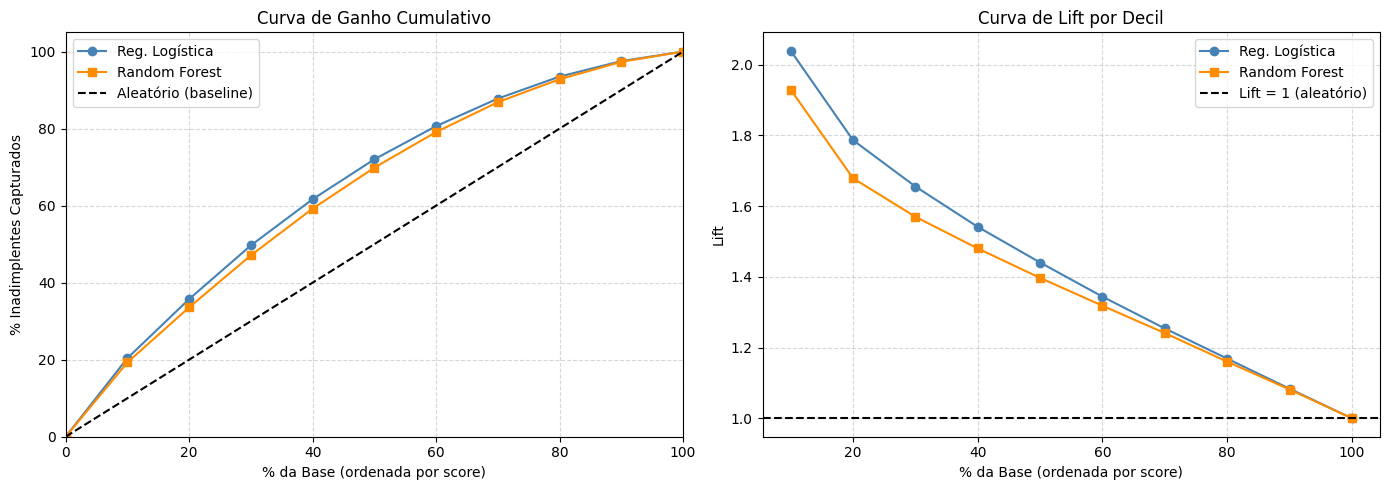

Cutoff ótimo (lucro máximo hipotético):
  Reg. Logística : threshold = 0.362  |  lucro = 6,417,900 USD (ilustrativo)
  Random Forest  : threshold = 0.402  |  lucro = 5,549,500 USD (ilustrativo)


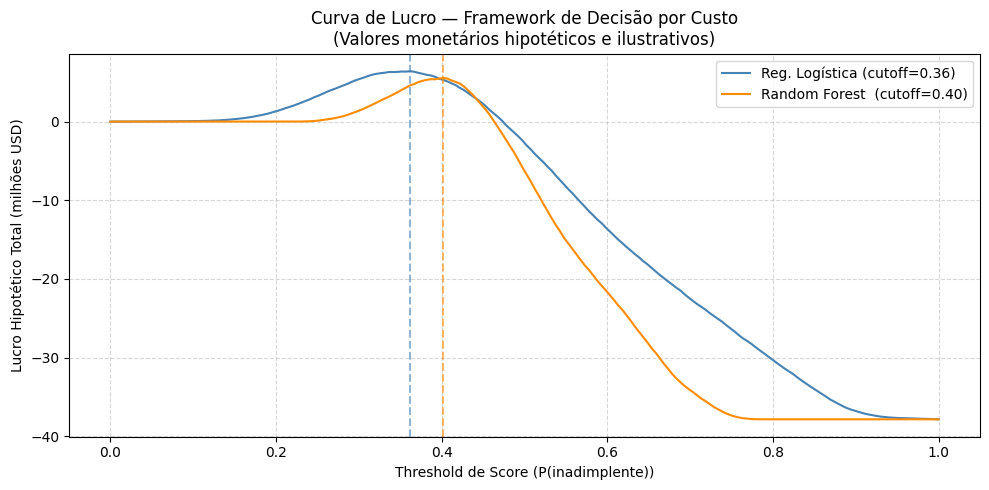

In [28]:
# =========================================================
# Função auxiliar: tabela de ganho/lift
# =========================================================
def tabela_lift(y_true, y_score, n_decis=10):
    """
    Retorna um DataFrame com:
    - Decil
    - Qtd. registros no decil
    - Qtd. inadimplentes capturados
    - % inadimplentes capturados (gain)
    - Lift = gain% / (1/n_decis)
    """
    df = pd.DataFrame({'score': y_score, 'target': y_true})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    df['decil'] = pd.qcut(df.index, n_decis, labels=False) + 1

    total_maus = df['target'].sum()

    tabela = (df.groupby('decil', observed=True)
                .agg(registros=('target', 'count'),
                     maus=('target', 'sum'))
                .reset_index())

    tabela['maus_acum']  = tabela['maus'].cumsum()
    tabela['gain_pct']   = tabela['maus_acum'] / total_maus * 100
    tabela['pct_base']   = (tabela['decil'] / n_decis) * 100
    tabela['lift']       = tabela['gain_pct'] / tabela['pct_base']

    return tabela


# =========================================================
# Tabelas de Lift
# =========================================================
tbl_lr = tabela_lift(y_test.values, y_prob_lr)
tbl_rf = tabela_lift(y_test.values, y_prob_rf)

print('=== Lift — Regressão Logística ===')
print(tbl_lr[['decil', 'registros', 'maus', 'maus_acum', 'gain_pct', 'lift']].to_string(index=False))

print()
print('=== Lift — Random Forest ===')
print(tbl_rf[['decil', 'registros', 'maus', 'maus_acum', 'gain_pct', 'lift']].to_string(index=False))

# Highlight: Gain@5% e Gain@10%
print()
print('=== Gain (% inadimplentes capturados) por corte ===' )
for modelo, tbl in [('Reg. Logística', tbl_lr), ('Random Forest', tbl_rf)]:
    g5  = tbl.loc[tbl['decil'] == 1,  'gain_pct'].values[0]
    g10 = tbl.loc[tbl['decil'] <= 2,  'gain_pct'].max()
    l5  = tbl.loc[tbl['decil'] == 1,  'lift'].values[0]
    l10 = tbl.loc[tbl['decil'] <= 2,  'lift'].min()
    print(f'  {modelo}:  Gain@5%={g5:.1f}%  Lift@5%={l5:.2f}x  |  Gain@10%={g10:.1f}%  Lift@10%={l10:.2f}x')


# =========================================================
# Gráfico Curva de Ganho
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gain ---
ax = axes[0]
x_base = [0] + tbl_lr['pct_base'].tolist()
ax.plot(x_base, [0] + tbl_lr['gain_pct'].tolist(),  marker='o', label='Reg. Logística', color='steelblue')
ax.plot(x_base, [0] + tbl_rf['gain_pct'].tolist(),  marker='s', label='Random Forest',  color='darkorange')
ax.plot([0, 100], [0, 100], 'k--', label='Aleatório (baseline)')
ax.set_xlabel('% da Base (ordenada por score)')
ax.set_ylabel('% Inadimplentes Capturados')
ax.set_title('Curva de Ganho Cumulativo')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

# --- Lift ---
ax = axes[1]
ax.plot(tbl_lr['pct_base'], tbl_lr['lift'], marker='o', label='Reg. Logística', color='steelblue')
ax.plot(tbl_rf['pct_base'], tbl_rf['lift'], marker='s', label='Random Forest',  color='darkorange')
ax.axhline(1.0, color='k', linestyle='--', label='Lift = 1 (aleatório)')
ax.set_xlabel('% da Base (ordenada por score)')
ax.set_ylabel('Lift')
ax.set_title('Curva de Lift por Decil')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =========================================================
# Curva de Lucro (profit curve)
# NOTA: os valores monetários abaixo são HIPOTÉTICOS e
# ilustrativos. Os dados originais do LendingClub estão
# em dólares americanos. Qualquer aplicação real exigiria
# valores calibrados à carteira e moeda correspondentes.
# =========================================================
CUSTO_APROVAR_MAU  = -2000   # perda estimada hipotética (USD)
GANHO_APROVAR_BOM  =   300   # ganho estimado hipotético (USD)

def curva_lucro(y_true, y_score, custo_mau, ganho_bom, n_pontos=200):
    y_arr = np.asarray(y_true)
    thresholds = np.linspace(0, 1, n_pontos)
    lucros = []
    for t in thresholds:
        # Classifica como 'bom' quem tem score < threshold  (score = P(inadimplente))
        aprovados = y_arr[y_score < t]
        if len(aprovados) == 0:
            lucros.append(0)
            continue
        maus_aprovados = aprovados.sum()
        bons_aprovados = len(aprovados) - maus_aprovados
        lucro = bons_aprovados * ganho_bom + maus_aprovados * custo_mau
        lucros.append(lucro)
    return thresholds, np.array(lucros)


thresh_lr, lucro_lr = curva_lucro(y_test.values, y_prob_lr, CUSTO_APROVAR_MAU, GANHO_APROVAR_BOM)
thresh_rf, lucro_rf = curva_lucro(y_test.values, y_prob_rf, CUSTO_APROVAR_MAU, GANHO_APROVAR_BOM)

cutoff_lr = thresh_lr[np.argmax(lucro_lr)]
cutoff_rf = thresh_rf[np.argmax(lucro_rf)]

print(f'Cutoff ótimo (lucro máximo hipotético):')
print(f'  Reg. Logística : threshold = {cutoff_lr:.3f}  |  lucro = {max(lucro_lr):,.0f} USD (ilustrativo)')
print(f'  Random Forest  : threshold = {cutoff_rf:.3f}  |  lucro = {max(lucro_rf):,.0f} USD (ilustrativo)')

plt.figure(figsize=(10, 5))
plt.plot(thresh_lr, lucro_lr / 1e6, label=f'Reg. Logística (cutoff={cutoff_lr:.2f})', color='steelblue')
plt.plot(thresh_rf, lucro_rf / 1e6, label=f'Random Forest  (cutoff={cutoff_rf:.2f})', color='darkorange')
plt.axvline(cutoff_lr, color='steelblue', linestyle='--', alpha=0.6)
plt.axvline(cutoff_rf, color='darkorange', linestyle='--', alpha=0.6)
plt.xlabel('Threshold de Score (P(inadimplente))')
plt.ylabel('Lucro Hipotético Total (milhões USD)')
plt.title('Curva de Lucro — Framework de Decisão por Custo\n'
          '(Valores monetários hipotéticos e ilustrativos)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
